In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import torch
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

from medmnist import PathMNIST
from torchvision import transforms

from src.models import TinyCNN
from src.client import Client
from src.server import Server
from src.reliability import ReliabilityTracker

In [2]:
from torchvision import transforms
from medmnist import PathMNIST

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = PathMNIST(
    split="train",
    transform=transform,
    download=True
)

test_dataset = PathMNIST(
    split="test",
    transform=transform,
    download=True
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 89996
Test samples: 7180


Image shape: torch.Size([3, 28, 28])
Label: [0]


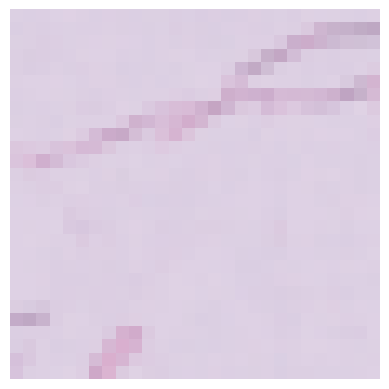

In [3]:
img, label = train_dataset[0]

print("Image shape:", img.shape)
print("Label:", label)

plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [4]:
from torch.utils.data import random_split

num_clients = 5

client_size = len(train_dataset) // num_clients

split_sizes = [client_size] * (num_clients - 1)

last_client_size = len(train_dataset) - sum(split_sizes)

split_sizes.append(last_client_size)

client_datasets = random_split(
    train_dataset,
    split_sizes
)

print("Number of client datasets:", len(client_datasets))

for i, ds in enumerate(client_datasets):
    print(f"Client {i}: {len(ds)} samples")

Number of client datasets: 5
Client 0: 17999 samples
Client 1: 17999 samples
Client 2: 17999 samples
Client 3: 17999 samples
Client 4: 18000 samples


In [5]:
from torch.utils.data import DataLoader

client_loaders = []

for ds in client_datasets:
    loader = DataLoader(
        ds,
        batch_size=32,
        shuffle=True
    )
    client_loaders.append(loader)

print("Created", len(client_loaders), "client loaders")

Created 5 client loaders


In [6]:
global_model = TinyCNN(num_classes=9)

tracker = ReliabilityTracker()

server = Server(
    global_model=global_model,
    reliability_tracker=tracker
)

print("Global model, tracker, and server created")

Global model, tracker, and server created


In [7]:
clients = []

for loader in client_loaders:

    model = TinyCNN(num_classes=9)

    model.load_state_dict(
        global_model.state_dict()
    )

    client = Client(
        model=model,
        train_loader=loader
    )

    clients.append(client)

print("Created", len(clients), "clients")

Created 5 clients


In [8]:
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Test loader ready")

Test loader ready


In [9]:
def evaluate(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            labels = labels.squeeze().long()

            outputs = model(images)

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

    return correct / total

In [10]:
rounds = 10

loss_history = []
acc_history = []
reliability_history = []

for r in range(rounds):

    print(f"\n========== ROUND {r+1} ==========")

    round_loss = 0
    round_reliability = []

    server.client_updates = []
    server.client_ids = []

    for client_id, client in enumerate(clients):

        loss = client.train(epochs=1)

        reliability = tracker.compute_reliability(
            client_id=client_id,
            loss=loss
        )

        server.add_client_update(
            client_id,
            client.get_weights()
        )

        round_loss += loss
        round_reliability.append(reliability)

        print(
            f"Client {client_id}: "
            f"Loss={loss:.4f}, "
            f"Reliability={reliability:.4f}"
        )

    global_weights = server.aggregate()

    for client in clients:
        client.set_weights(global_weights)

    global_model.load_state_dict(global_weights)

    accuracy = evaluate(
        global_model,
        test_loader
    )

    avg_reliability = (
        sum(round_reliability)
        / len(round_reliability)
    )

    loss_history.append(round_loss)

    acc_history.append(accuracy)

    reliability_history.append(avg_reliability)

    print(
        f"Global Accuracy: {accuracy:.4f}"
    )


========== ROUND 1 ==========
Client 0: Loss=1.4160, Reliability=0.8237
Client 1: Loss=1.4580, Reliability=0.8115
Client 2: Loss=1.4169, Reliability=0.8235
Client 3: Loss=1.4273, Reliability=0.8204
Client 4: Loss=1.4272, Reliability=0.8204
Global Accuracy: 0.5660

========== ROUND 2 ==========
Client 0: Loss=1.2883, Reliability=0.7952
Client 1: Loss=1.2684, Reliability=0.7977
Client 2: Loss=1.2464, Reliability=0.8108
Client 3: Loss=1.2687, Reliability=0.8011
Client 4: Loss=1.2926, Reliability=0.7923
Global Accuracy: 0.7457

========== ROUND 3 ==========
Client 0: Loss=1.1939, Reliability=0.8264
Client 1: Loss=1.1929, Reliability=0.8248
Client 2: Loss=1.1655, Reliability=0.8417
Client 3: Loss=1.1515, Reliability=0.8453
Client 4: Loss=1.1873, Reliability=0.8279
Global Accuracy: 0.7430

========== ROUND 4 ==========
Client 0: Loss=1.1236, Reliability=0.8600
Client 1: Loss=1.1716, Reliability=0.8366
Client 2: Loss=1.1388, Reliability=0.8570
Client 3: Loss=1.1330, Reliability=0.8585
Client

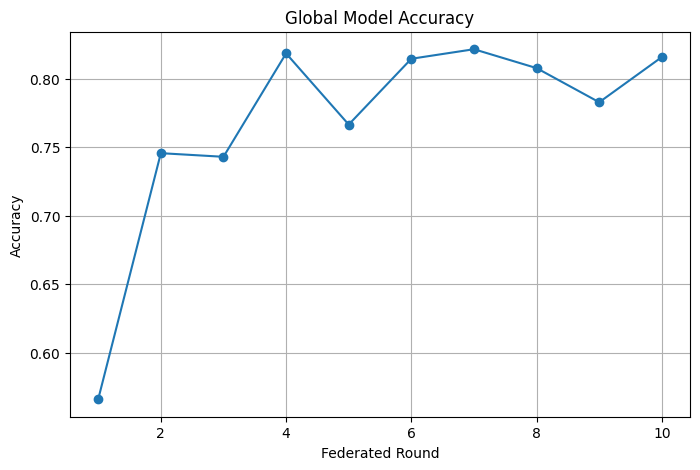

In [11]:
plt.figure(figsize=(8,5))
plt.plot(range(1, rounds+1), acc_history, marker="o")
plt.xlabel("Federated Round")
plt.ylabel("Accuracy")
plt.title("Global Model Accuracy")
plt.grid(True)
plt.show()

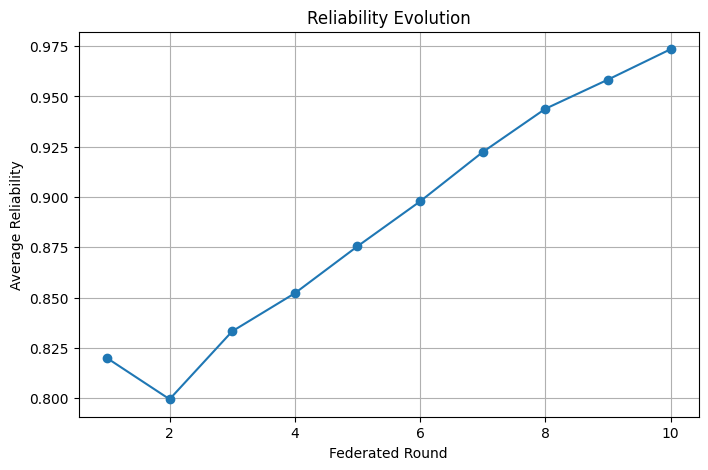

In [12]:
plt.figure(figsize=(8,5))
plt.plot(range(1, rounds+1), reliability_history, marker="o")
plt.xlabel("Federated Round")
plt.ylabel("Average Reliability")
plt.title("Reliability Evolution")
plt.grid(True)
plt.show()

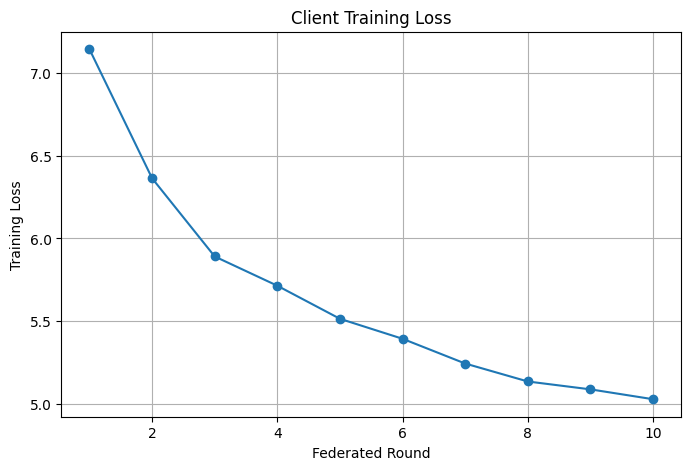

In [13]:
plt.figure(figsize=(8,5))
plt.plot(range(1, rounds+1), loss_history, marker="o")
plt.xlabel("Federated Round")
plt.ylabel("Training Loss")
plt.title("Client Training Loss")
plt.grid(True)
plt.show()

In [14]:
print("Final Accuracy:", acc_history[-1])
print("Final Reliability:", reliability_history[-1])
print("Final Loss:", loss_history[-1])

Final Accuracy: 0.8158774373259053
Final Reliability: 0.9735095024108886
Final Loss: 5.027360887711679
